## Устанавливаем нужные пакеты и потом импортируем их

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install sounddevice
!pip install scipy
!pip install librosa soundfile scipy

!apt-get update
!apt-get install -y portaudio19-dev
!pip install pyaudio

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (1,830 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

## Шумы

*Белый шум* - стационарный шум, спектральные составляющие которого равномерно распределены по всему диапазону задействованных частот.
В нем частоты всего звукового диапазона, который человеческий слух может воспринять: от 20 до 20 000 Гц.
Другими словами, белый шум – это «смесь» звуков, воспроизводимых одновременно на всех частотах, которые воспринимает наше ухо.


*Аддитивный белый гауссовский шум (AWGN)* - базовая модель шума, используемая в теории информации для имитации эффекта многих случайных процессов, происходящих в природе. Модификаторы обозначают специфические характеристики:

**Аддитивный**, потому что он добавляется к любому шуму, который может быть присущ информационной системе.

**Белый шум** относится к идее о том, что он имеет равномерную спектральную плотность мощности во всей полосе частот информационной системы. Это аналогия с белым цветом, который может быть реализован за счет равномерного излучения на всех частотах в видимом спектре.

**Гауссовский**, потому что он имеет нормальное распределение во временной области со средним значением во временной области, равным нулю (гауссовский процесс).



In [ ]:
# глобальные переменные, которые нам нужны для генерации всех шумов. Можно обойтись и без них.

duration = 5  # Продолжительность в секундах
sample_rate = 4100  # Частота дискретизации в Гц

In [ ]:
# счиетаем, сколько элементов будем генерировать.
#Не забываем привести к инту, так как и длительность (duration) и частота (sample_rate) могут быть вещественными

num_samples = int(duration * sample_rate)

In [ ]:
# генерируем просто белый шум, не озадачиваесь его распределением. И печатаем.

white_noise_simple = np.random.random(num_samples)

print(white_noise_simple)

[0.87995256 0.82358797 0.85098622 ... 0.68791651 0.8398225  0.47691742]


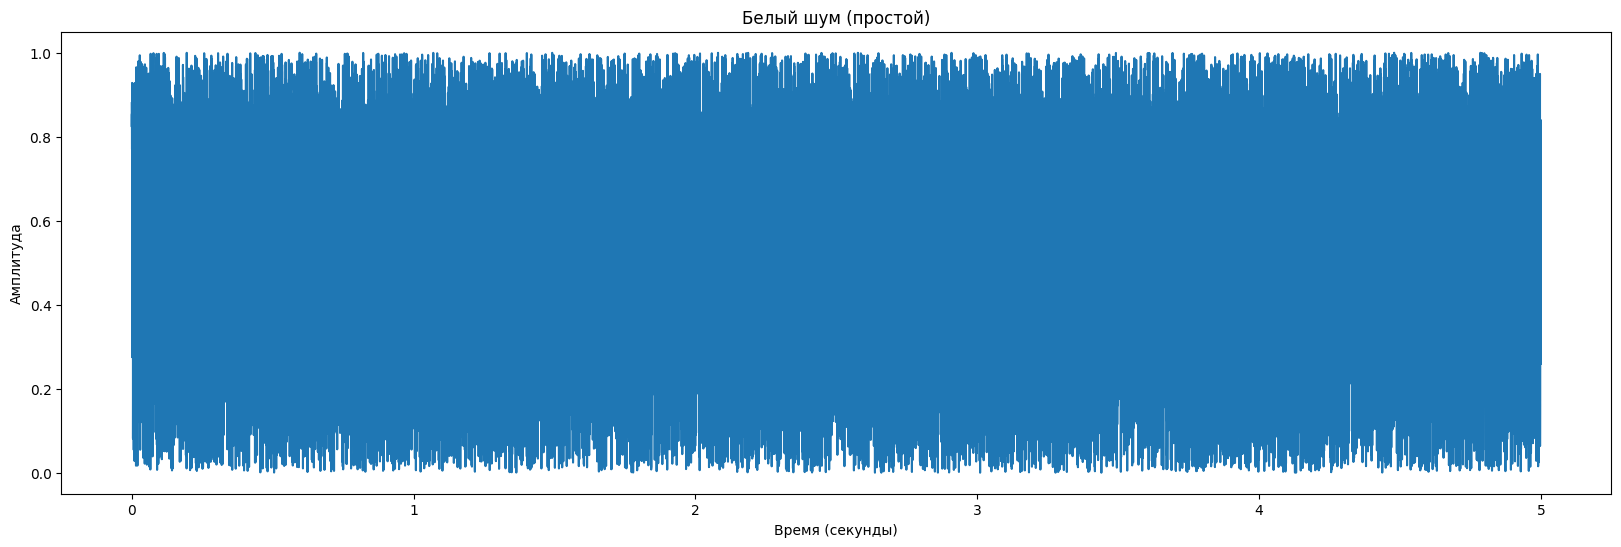

In [ ]:
# отрисовываем, что получилось

# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(white_noise_simple))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, white_noise_simple)

# заголовки
plt.title('Белый шум (простой)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()


In [ ]:
# слушаем, что получилось
sd.play(white_noise_simple, sample_rate)
sd.wait()

PortAudioError: Error querying device -1

In [ ]:
# генерируем гауссовский белый шум
# loc - медиана
# scale - стандартная девиация

white_noise_g = np.random.normal(loc = 0, scale = 1, size = num_samples)

print(white_noise_g)

[-1.50244018  0.33226175 -0.1614607  ...  0.02552635  0.34412328
 -0.13672863]


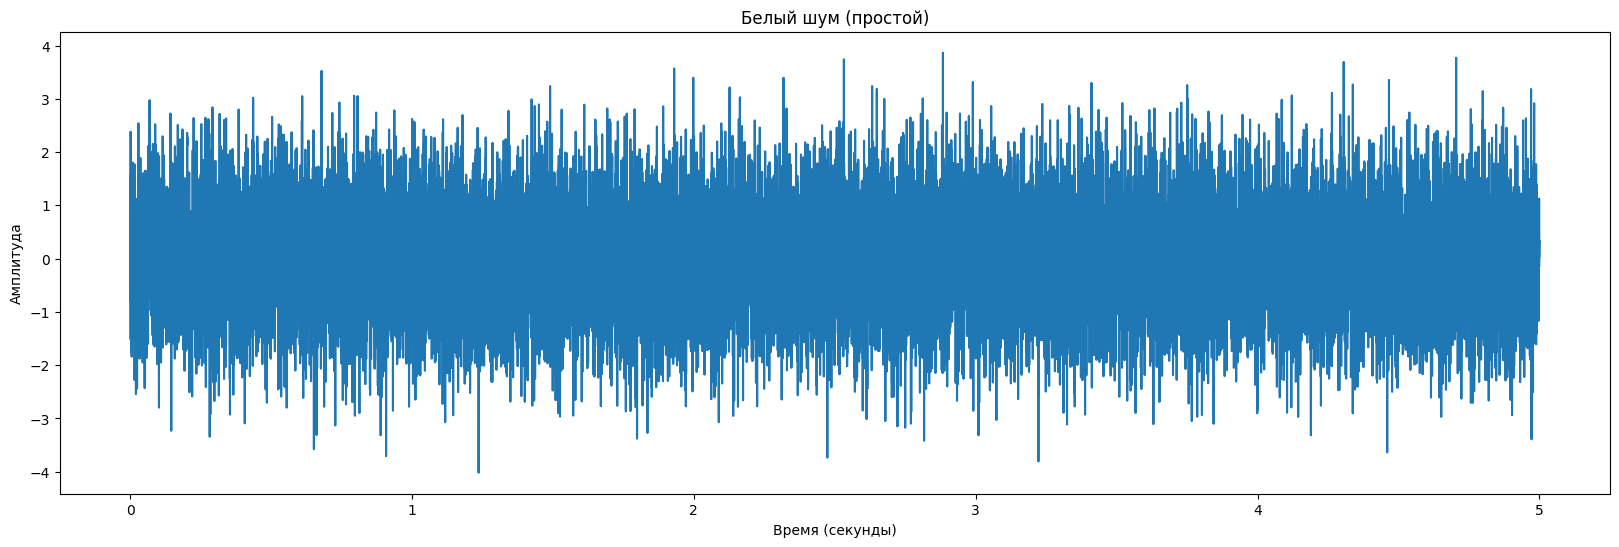

In [ ]:
# отрисовываем, что получилось

# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(white_noise_g))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, white_noise_g)

# заголовки
plt.title('Белый шум (простой)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()


In [ ]:
# слушаем, что получилось
sd.play(white_noise_g, sample_rate)
sd.wait()

PortAudioError: Error querying device -1

/tmp/ipykernel_2567/2795709816.py:25: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([c0, c1],


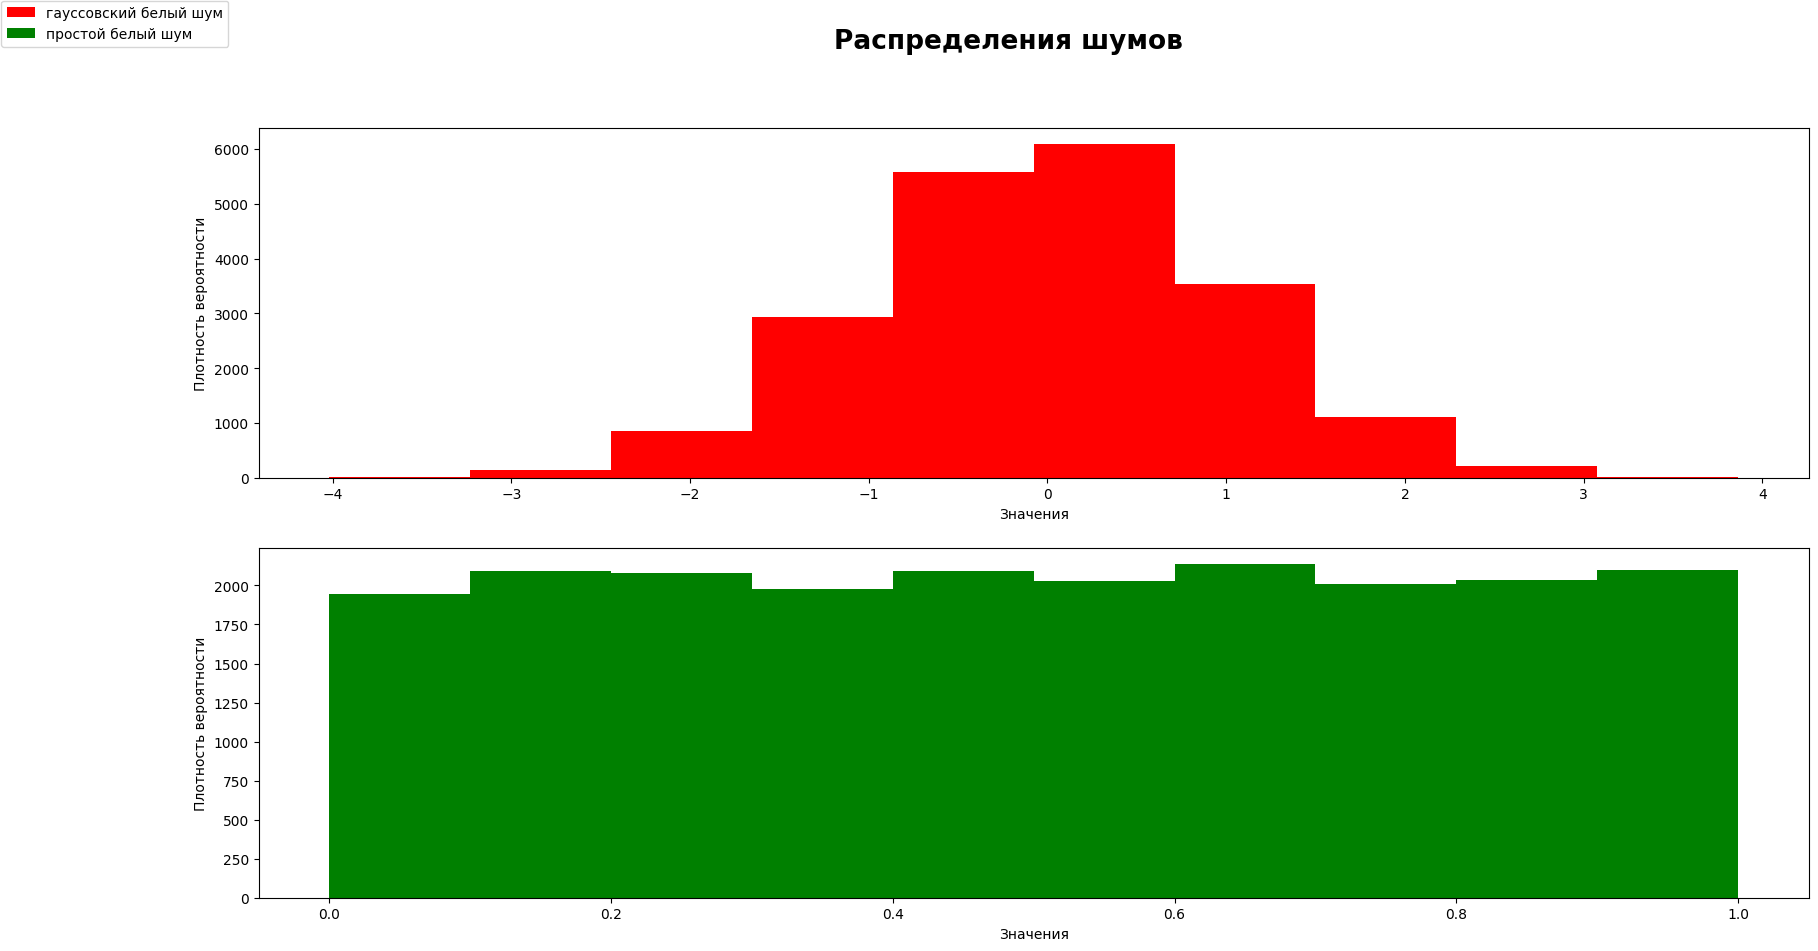

In [ ]:
# давайте сравним распеределения двух шумов. Это можно сделать с помощью функции hist



# хотим нарисовать все на одном рисунке. Нам нужно 2 рисунка, один под другим.
fig, axs = plt.subplots(2, 1, figsize=(20, 10))


# общий заголовок для всей картинки
fig.suptitle('Распределения шумов', fontsize=19, fontweight='bold')

labels = ["гауссовский белый шум", "простой белый шум"]

# определяем, что будем отрисовывать на 1 графике. По x - амплитуды, по y - плотность вероятности
c0 = axs[0].hist(white_noise_g, color="red")
axs[0].set_xlabel('Значения')
axs[0].set_ylabel('Плотность вероятности')

# определяем, что будем отрисовывать. По x - амплитуды, по y - плотность вероятности
c1 = axs[1].hist(white_noise_simple, color ="green")
axs[1].set_xlabel('Значения')
axs[1].set_ylabel('Плотность вероятности')

# отрисовываем общую легенду
fig.legend([c0, c1],
           labels=labels,
           loc='upper left',
           borderaxespad=0.1)

plt.show()


*Коричневый шум* - больше выделяются низкие частоты (имеют высокие амплитуды). Получается интегрирвание белого шума.

Для этого нужно:
Создать белый гауссовкий шум с нулевой медианой.
Вычислить кумулятивную сумму полученного белого шума
От кумулятивной суммы отнять медианное значение
Отмасштабировать

На заметку:
Коричневый шум имеет ОГРОМНОЕ количество энергии на очень низких частотах и теоретически бесконечную энергию на частоте 0 Гц. Это, скорее всего, перегрузит любую разумную систему, поэтому вам, вероятно, понадобится коричневый шум с «ограниченной полосой пропускания». Самый простой способ сделать это — использовать фильтр верхних и нижних частот первого порядка вместо интегратора. Например, фильтр верхних частот на частоте 20 Гц и фильтр нижних частот на частоте 40 Гц.


In [ ]:
# белый шум у нас уже есть в переменной white_noise_g (сгенерирован в ячейках выше). Давайте просто работать с ним
# Создайте коричневый шум

# 1. Вычисляем кумулятивную сумму (интегрирование белого шума)
integrated_signal = np.cumsum(white_noise_g)

# 2. Отнимаем МЕДИАННОЕ значение (строго по условию задания, исправляем ошибку старого кода)
median_value = np.median(integrated_signal)
centered_signal = integrated_signal - median_value

# 3. Масштабируем (нормализуем к диапазону [-1, 1], деля на максимальный модуль)
max_amplitude = np.max(np.abs(centered_signal))
my_brown_noise = centered_signal / max_amplitude

# Выводим результаты
print(my_brown_noise)
print(white_noise_g)

[0.0509079  0.05364839 0.05231666 ... 0.35576406 0.35860239 0.35747465]
[-1.50244018  0.33226175 -0.1614607  ...  0.02552635  0.34412328
 -0.13672863]


In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(brown_noise))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, brown_noise)

# заголовки
plt.title('Коричневый шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()



NameError: name 'brown_noise' is not defined

In [ ]:
# слушаем, что получилось
sd.play(brown_noise, sample_rate)
sd.wait()

NameError: name 'brown_noise' is not defined

*Розовый шум* или фликкер (мерцающий) шум - очень похож на белый.

Розовый шум может быть сгенерирован путем первой генерации сигнала белого шума, преобразования его Фурье, затем деления амплитуд различных частотных составляющих на квадратный корень из частоты (в одном измерении) или на частоту (в двух измерениях) и т.д. Это эквивалентно пространственной фильтрации (свертке) сигнала белого шума с помощью фильтра от белого к розовому. Для сигнала длины N в одном измерении фильтр имеет следующий вид:

![Alt text](image-1.png)

In [ ]:
# применение фильтра для генерации розового шума

N = len(white_noise_g)
N2 = N//2

print(N)
print(N2)

pink_noise_f = []

for el in white_noise_g:

    s = 0
    for k in range(1,N2):
        s += 1/np.sqrt(k) * np.cos(2*np.pi*k*(el-1)/N)
    s *=2
    s = s + 1 + np.cos(np.pi*(el-1))/np.sqrt(N2)

    pink_noise_f.append(s/N)
    print(len(pink_noise_f))


Выходные данные были обрезаны до нескольких последних строк (5000).
15501
15502
15503
15504
15505
15506
15507
15508
15509
15510
15511
15512
15513
15514
15515
15516
15517
15518
15519
15520
15521
15522
15523
15524
15525
15526
15527
15528
15529
15530
15531
15532
15533
15534
15535
15536
15537
15538
15539
15540
15541
15542
15543
15544
15545
15546
15547
15548
15549
15550
15551
15552
15553
15554
15555
15556
15557
15558
15559
15560
15561
15562
15563
15564
15565
15566
15567
15568
15569
15570
15571
15572
15573
15574
15575
15576
15577
15578
15579
15580
15581
15582
15583
15584
15585
15586
15587
15588
15589
15590
15591
15592
15593
15594
15595
15596
15597
15598
15599
15600
15601
15602
15603
15604
15605
15606
15607
15608
15609
15610
15611
15612
15613
15614
15615
15616
15617
15618
15619
15620
15621
15622
15623
15624
15625
15626
15627
15628
15629
15630
15631
15632
15633
15634
15635
15636
15637
15638
15639
15640
15641
15642
15643
15644
15645
15646
15647
15648
15649
15650
15651
15652
15653
15654
15655
15

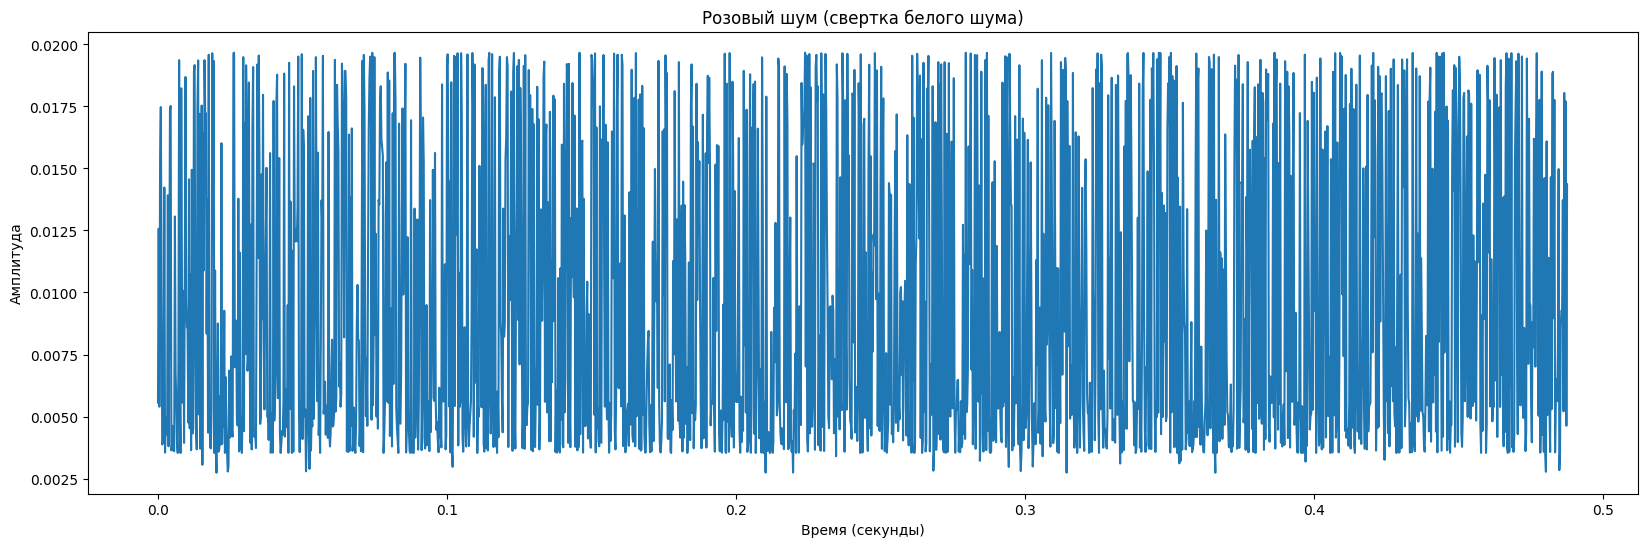

In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(pink_noise_f))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis[:2000], pink_noise_f[:2000])

# заголовки
plt.title('Розовый шум (свертка белого шума)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()

Задание. Сгенерите розовый шум путем первой генерации сигнала белого шума, преобразования его Фурье, затем деления амплитуд различных частотных составляющих на квадратный корень из частоты.

Вам понадобятся функции np.fft.rfft , np.real , np.sqrt

In [ ]:
# Задание. Сгенерировать розовый шум с помощью преобразования Фурье.
# Переменные num_samples и sample_rate должны быть заданы в ячейках выше.

# 1. Генерируем первичный сигнал белого шума (нормальное распределение)
initial_white_noise = np.random.normal(loc=0.0, scale=1.0, size=num_samples)

# 2. Выполняем прямое преобразование Фурье (переход из времени в частоты)
fourier_spectrum = np.fft.rfft(initial_white_noise)

# 3. Получаем массив частотных составляющих
frequencies = np.fft.rfftfreq(num_samples, d=1.0/sample_rate)

# 4. Делим амплитуды на квадратный корень из частоты.
# Важно: срез [1:] используем, чтобы пропустить 0 Гц и избежать ошибки деления на ноль
fourier_spectrum[1:] = fourier_spectrum[1:] / np.sqrt(frequencies[1:])

# 5. Выполняем обратное преобразование Фурье (собираем сигнал обратно)
inverse_fourier_signal = np.fft.irfft(fourier_spectrum, n=num_samples)

# 6. Извлекаем вещественную часть сигнала (строго по требованию задания)
real_signal = np.real(inverse_fourier_signal)

# 7. Масштабируем сигнал (нормализация к диапазону [-1, 1])
max_val = np.max(np.abs(real_signal))
pink_noise = real_signal / max_val

# Выводим результат
print(pink_noise)

[-0.04486599 -0.02425609  0.05502061 ... -0.10396645 -0.13314986
 -0.02116202]


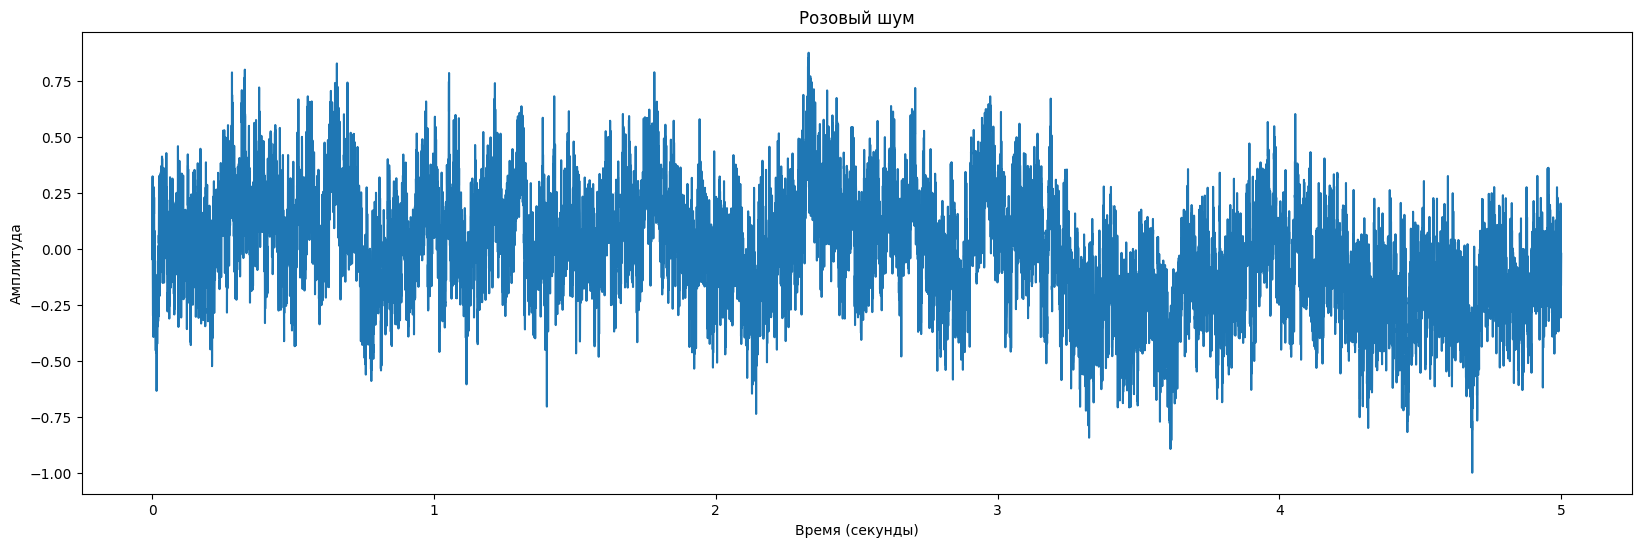

In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(pink_noise))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, pink_noise)

# заголовки
plt.title('Розовый шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()

In [ ]:
# слушаем, что получилось
sd.play(pink_noise_f, sample_rate)
sd.wait()

PortAudioError: Error querying device -1

In [ ]:
# слушаем, что получилось
sd.play(pink_noise, sample_rate)
sd.wait()

PortAudioError: Error querying device -1

*Черный шум*
Или тишина. Или шум на частотах, которые мы не слышим.

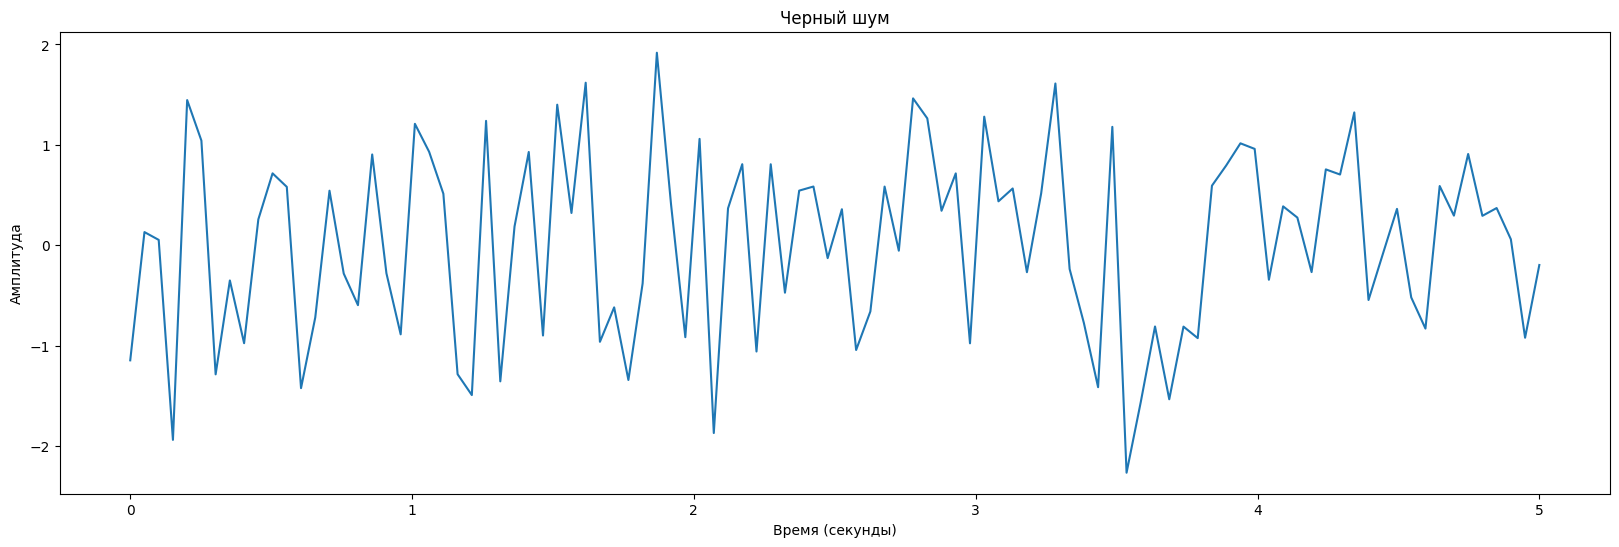

In [ ]:
# количество элементов в записи сигнала
num_samples = int(duration * sample_rate)
freq1 = 20000
freq2 = 25000

# Частоты, на которых будем генерировать
num_frequencies = 100  # Количество случайных частот
frequencies = np.linspace(freq1, freq2, num_frequencies) # лист с частотами

black_noise = np.zeros(num_samples)   # подготовили лист для записи сигнала
time_axis = np.arange(num_samples) / sample_rate   # задали временную ось

amplitudes = np.random.normal(0, 1, num_frequencies)  # опять сгенерировали белый гауссовский шум

black_noise = np.zeros(num_samples)
time_axis = np.arange(num_samples) / sample_rate

for i in range(num_frequencies):
        # надо описать, откуда вы взяли эту формулу
        black_noise += amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * time_axis)

#black_noise /= np.max(np.abs(black_noise))  # Нормализация амплитуды к [-1, 1]


# Визуализация
time_axis = np.linspace(0, duration, len(amplitudes))
plt.figure(figsize=(20, 6))
plt.plot(time_axis, amplitudes)
plt.title('Черный шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.show()


In [ ]:
sd.play(amplitudes, freq1)
sd.wait()

PortAudioError: Error querying device -1

Черный шум - как излучение абсолютно черного тела

Cпектральная плотность мощности излучения известна (непрерывную функцию частоты - f и температуры - T):

![Alt text](image.png)

kB - постоянная Больцмана
h  - Постоянная Планка
c  - скорость света

Поскольку выходная величина должна быть выражена в децибелах, чтобы иметь смысл для звука, мы просто используем логарифмическую шкалу и добавляем смещение (усиление), чтобы нормализовать пик до 0. Уравнение кривой эквалайзера равно:

![Alt text](image-2.png)

Еквалайзер применяем к белому шуму

In [ ]:
import scipy

kb =  scipy.constants.k
h = scipy.constants.physical_constants['Planck constant'][0]
c = scipy.constants.c

print(kb)
print(h)
print(c)

T = 17*1/np.power(10, 9)  #Температура 17 нанокельвинов
G = 10

coef1 = 2*h/(c*c*T*T*T)
coef2 = h/(kb*T)

freq1 = 1000

# количество элементов в записи сигнала. Для 17 нанокельвинов полоса пропускания шума будет от 1Гц до 12 кГц
num_samples = int(duration * freq1)


# Частоты, на которых будем генерировать

black_noise = np.zeros(num_samples)   # подготовили лист для записи сигнала
time_axis = np.arange(num_samples) / sample_rate   # задали временную ось



black_noise = np.zeros(num_samples)
time_axis = np.arange(num_samples) / sample_rate
eq = 10 * np.log(coef1*np.power(freq1,3)/(np.exp(coef2*freq1)-1)) + 10 # эквалайзер

white_noise_g = np.random.normal(loc = 0, scale = 1, size = num_samples) # опять белый шум

black_noise = white_noise_g + eq # применяем преобразование к белому шуму

black_noise /= np.max(np.abs(black_noise))  # Нормализация амплитуды к [-1, 1]



1.380649e-23
6.62607015e-34
299792458.0


In [ ]:
# так звучит черное тело

sd.play(black_noise, freq1)
sd.wait()

PortAudioError: Error querying device -1

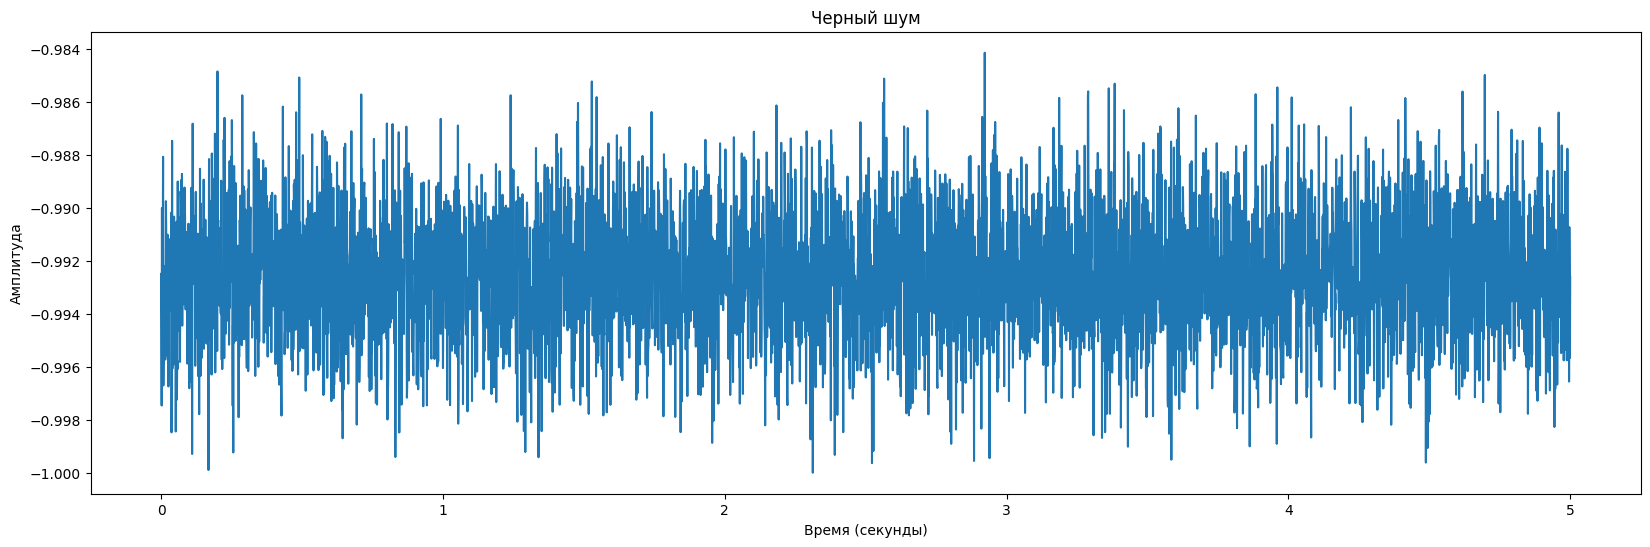

In [ ]:
# Визуализация
time_axis = np.linspace(0, duration, len(black_noise))
plt.figure(figsize=(20, 6))
plt.plot(time_axis, black_noise)
plt.title('Черный шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.show()

## Генерация временных рядов

Этот код создает пример временного ряда, представленного как синусоида с добавлением случайного шума. Это просто пример, можно изменить генерацию данных в соответствии с вашими потребностями.

In [ ]:
duration = 5  # Продолжительность в секундах
sample_rate = 4100  # Частота дискретизации в Гц

num_points = duration*sample_rate  # количество точек

time_points = np.linspace(0, duration, num_points)  # Создаем равномерные временные точки от 0 до 5 секунд

white_noise_base = np.random.normal(0,1,size=num_points)  # Генерим белый шум

values = 10*np.sin(4*time_points*np.pi) # вычисляем амплитуды сигнала по синусоидальному закону

values_noise = values + white_noise_base # зашумляем сигнал



/tmp/ipykernel_2567/3043892488.py:27: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([c0, c1, c2],


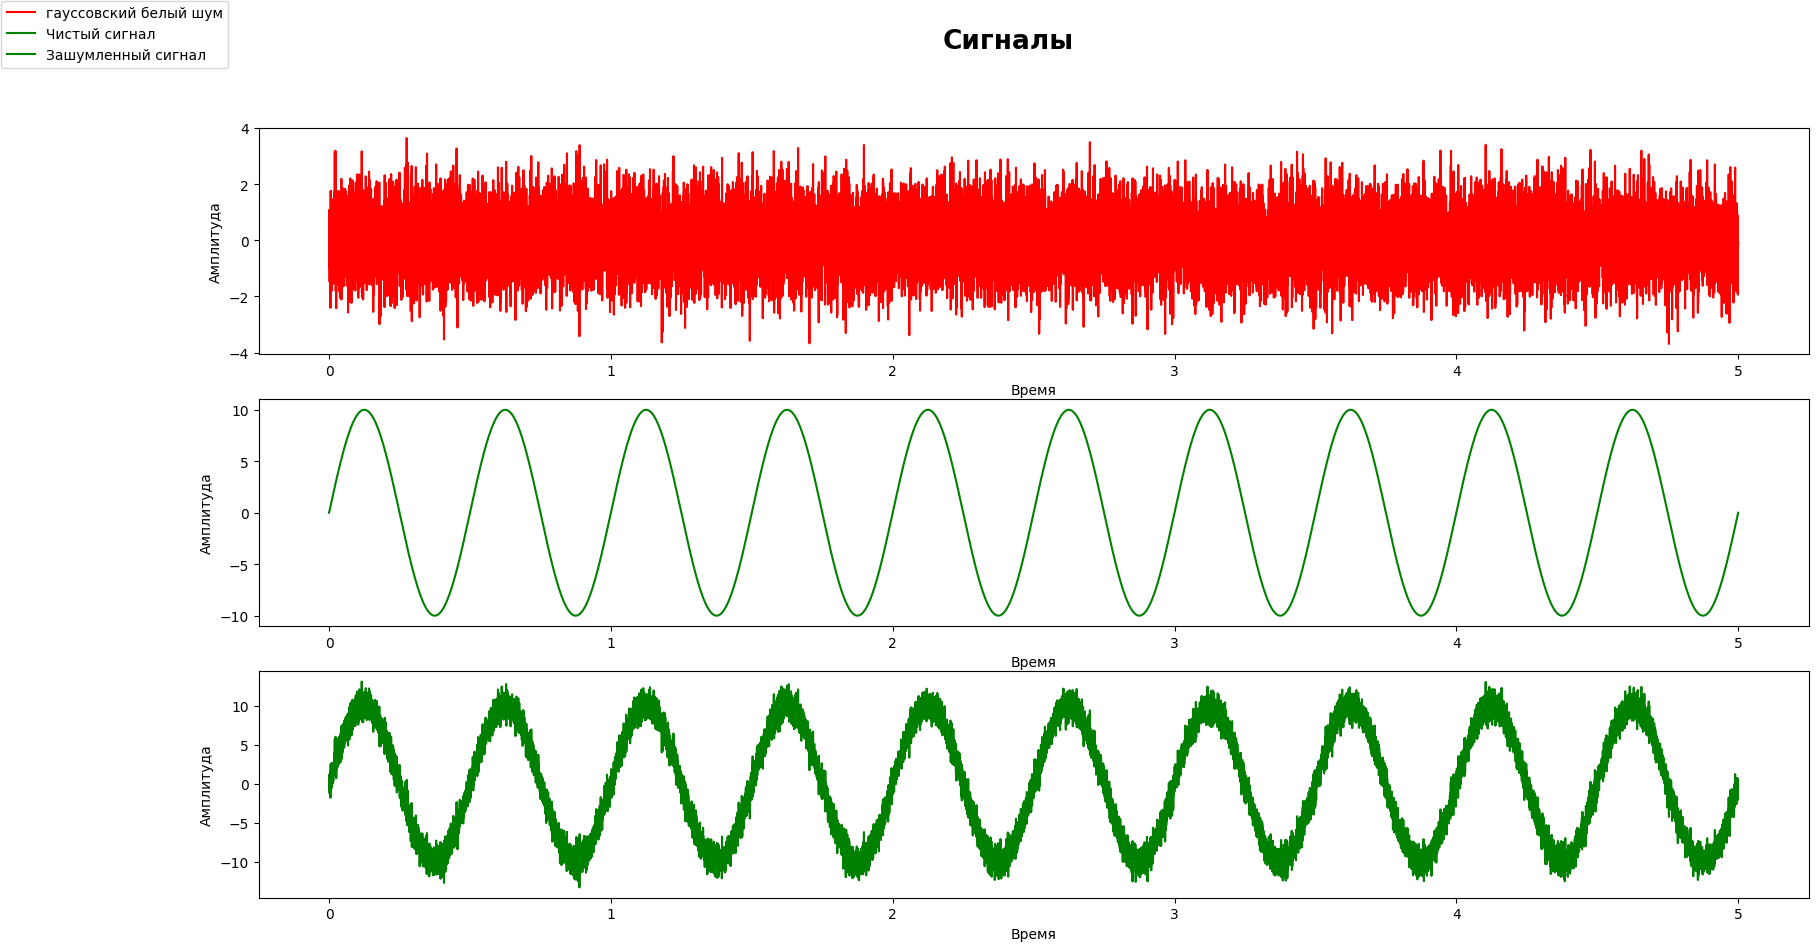

In [ ]:
# Отрисовываем
# хотим нарисовать все на одном рисунке. Нам нужно 3 рисунка, один под другим.
fig, axs = plt.subplots(3, 1, figsize=(20, 10))


# общий заголовок для всей картинки
fig.suptitle('Сигналы', fontsize=19, fontweight='bold')

labels = ["гауссовский белый шум", "Чистый сигнал", "Зашумленный сигнал"]

# определяем, что будем отрисовывать на 1 графике. По x - время, по y - амплитуды
c0 = axs[0].plot(time_points, white_noise_base, color="red")
axs[0].set_xlabel('Время')
axs[0].set_ylabel('Амплитуда')

# определяем, что будем отрисовывать. По x - время, по y - амплитуды
c1 = axs[1].plot(time_points, values, color="green")
axs[1].set_xlabel('Время')
axs[1].set_ylabel('Амплитуда')

# определяем, что будем отрисовывать. По x - время, по y - амплитуды
c2 = axs[2].plot(time_points, values_noise, color="green")
axs[2].set_xlabel('Время')
axs[2].set_ylabel('Амплитуда')

# отрисовываем общую легенду
fig.legend([c0, c1, c2],
           labels=labels,
           loc='upper left',
           borderaxespad=0.1)

